# Splitting, Nested CV, and Data Leakage — SOLUTION Notebook
### BBBP (blood–brain barrier permeability) dataset

**What you will learn**
- Split chemical datasets using random, scaffold, and time-based strategies with RDKit
- Implement nested cross-validation to tune hyperparameters without touching the test set
- Plot learning curves and validation curves to diagnose underfitting and overfitting
- Detect and fix a data leakage bug in a preprocessing pipeline

This is the **worked solution**. Discussion-question answers are inline in shaded
markdown blocks marked **Answer:**. A blanks version for students (with `# TODO`
cells instead of filled-in code) can be generated from this once you're happy with it.

> Runtime: end‑to‑end this notebook takes **~4–5 minutes** on Colab's free CPU runtime
> (the nested CV and learning/validation curve cells are the slow ones — each is
> flagged below).


## 1. Set up the environment

We need `rdkit` (cheminformatics: SMILES parsing, scaffolds, fingerprints, descriptors),
`scikit-learn` (splitting, models, CV, metrics), and the usual `pandas`/`numpy`/`matplotlib`.

`deepchem` is **not required** below — we implement scaffold splitting ourselves with
RDKit so students see exactly what's happening inside it. If you'd rather use DeepChem's
built-in `dc.splits.ScaffoldSplitter`, a comment shows where to swap it in.


In [1]:
# Colab: uncomment the line below on first run
# !pip install -q rdkit scikit-learn pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, DataStructs, Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, GridSearchCV,
    learning_curve, validation_curve,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import roc_auc_score

RDLogger.DisableLog("rdApp.*")   # RDKit is chatty about odd valences/stereo in BBBP; silence it
RNG_SEED = 42
np.random.seed(RNG_SEED)

print("Setup OK.")


Setup OK.


## 2. Explore the dataset

We pull the standard 2050-molecule BBBP table (Martins et al., 2012 — MoleculeNet's
canonical mirror). `p_np` is the label: **1 = penetrates the blood–brain barrier,
0 = does not.**

**A note before you trust any of this data:** the instructions say *"confirm the
dataset loads and SMILES parse cleanly"* for a reason — this exact mirror has a few
rows with missing SMILES and a handful of duplicated structures with **conflicting
labels**. Real datasets are messy; part of the exercise is catching that before it
contaminates your splits.


In [2]:
url = "https://raw.githubusercontent.com/GLambard/Molecules_Dataset_Collection/master/latest/BBBP.csv"
df_raw = pd.read_csv(url)
print(f"Raw rows: {len(df_raw)}")
df_raw.head()


Raw rows: 2050


,Unnamed: 0,num,name,p_np,smiles
0,0,1,Propanolol,1,CC(C)NCC(O)COC1:C:C:C:C2:C:C:C:C:C:1:2.[Cl]
1,1,2,Terbutylchlorambucil,1,CC(C)(C)OC(=O)CCCC1:C:C:C(N(CCCl)CCCl):C:C:1
2,2,3,40730,1,CC1COC2:C(N3CCN(C)CC3):C(F):C:C3:C(=O):C(C(=O)...
3,3,4,24,1,CC(=O)NCCCOC1:C:C:C:C(CN2CCCCC2):C:1
4,4,5,cloxacillin,1,CC1:O:N:C(C2:C:C:C:C:C:2Cl):C:1C(=O)N[C@@H]1C(...


In [3]:
# --- Clean: drop missing SMILES, canonicalize, drop unparseable rows ---
df = df_raw.dropna(subset=["smiles"]).copy()
print(f"Dropped {len(df_raw) - len(df)} rows with missing SMILES -> {len(df)} remain")

def canonicalize(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol) if mol is not None else None

df["canon_smiles"] = df["smiles"].apply(canonicalize)
n_fail = df["canon_smiles"].isna().sum()
print(f"SMILES that failed to parse: {n_fail}")
df = df.dropna(subset=["canon_smiles"]).reset_index(drop=True)

# --- Duplicate check on the CANONICAL string, not the raw one (raw-string dupes undercount) ---
n_dupe_raw = df["smiles"].duplicated().sum()
n_dupe_canon = df["canon_smiles"].duplicated().sum()
print(f"Duplicated raw SMILES strings:      {n_dupe_raw}")
print(f"Duplicated CANONICAL SMILES:        {n_dupe_canon}  <- this is the number that matters")

# Do any duplicated structures carry conflicting labels? (a real data-quality landmine)
dupe_mask = df.duplicated("canon_smiles", keep=False)
conflicts = df[dupe_mask].groupby("canon_smiles")["p_np"].nunique()
n_conflict = (conflicts > 1).sum()
print(f"Duplicate groups with CONFLICTING p_np labels: {n_conflict} / {len(conflicts)} duplicate groups")

# Resolve: keep first occurrence of each canonical structure (drops the conflicts too)
df = df.drop_duplicates("canon_smiles").reset_index(drop=True)
print(f"Final clean dataset: {len(df)} unique molecules")


Dropped 11 rows with missing SMILES -> 2039 remain


SMILES that failed to parse: 0
Duplicated raw SMILES strings:      64
Duplicated CANONICAL SMILES:        64  <- this is the number that matters
Duplicate groups with CONFLICTING p_np labels: 10 / 60 duplicate groups
Final clean dataset: 1975 unique molecules


p_np
0     474
1    1501
Name: count, dtype: int64
BBB-positive fraction: 0.760


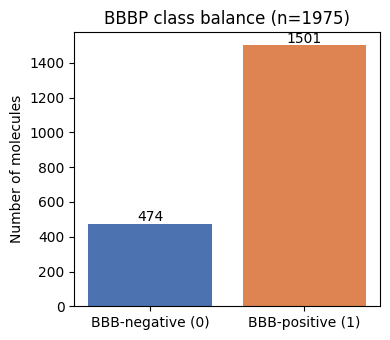

In [4]:
# --- Class balance ---
class_counts = df["p_np"].value_counts().sort_index()
pos_rate = df["p_np"].mean()
print(class_counts)
print(f"BBB-positive fraction: {pos_rate:.3f}")

fig, ax = plt.subplots(figsize=(4, 3.5))
ax.bar(["BBB-negative (0)", "BBB-positive (1)"], class_counts.values,
       color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Number of molecules")
ax.set_title(f"BBBP class balance (n={len(df)})")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 15, str(v), ha="center")
plt.tight_layout()
plt.show()


> **Answer — Warm-up Q1:** *What fraction of molecules are BBB-positive? Would you
> expect this class imbalance to affect AUC-ROC? What about accuracy?*
>
> About **76–77%** of molecules are BBB-positive (roughly a 3:1 imbalance). AUC-ROC is
> **rank-based** — it asks "does the model score positives higher than negatives on
> average?" — so it's fairly robust to this level of imbalance (it would only degrade
> as imbalance gets much more extreme, e.g. 50:1, where the minority class contributes
> too few pairs to estimate ranking reliably). **Accuracy is the one to distrust here**:
> a trivial classifier that predicts "BBB-positive" for everything already scores
> ~76% accuracy without learning anything. If you report accuracy on this dataset,
> always report it next to the majority-class baseline, or use balanced accuracy /
> AUC / F1 instead.


## 3. Implement splitting strategies

We featurize once (Morgan/ECFP4 fingerprints — 1024-bit, radius 2) and reuse `X`, `y`
across every split and model below.


In [5]:
def featurize_morgan(smiles_list, n_bits=1024, radius=2):
    X = np.zeros((len(smiles_list), n_bits), dtype=int)
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        bv = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
        DataStructs.ConvertToNumpyArray(bv, X[i])
    return X

X = featurize_morgan(df["canon_smiles"])
y = df["p_np"].values
print(X.shape, y.shape)


(1975, 1024) (1975,)


### 3a. Random split

In [6]:
train_idx_rand, test_idx_rand = train_test_split(
    np.arange(len(df)), test_size=0.2, stratify=y, random_state=RNG_SEED
)
print(f"Random split: {len(train_idx_rand)} train / {len(test_idx_rand)} test")
print(f"  train pos rate: {y[train_idx_rand].mean():.3f}   test pos rate: {y[test_idx_rand].mean():.3f}")


Random split: 1580 train / 395 test
  train pos rate: 0.760   test pos rate: 0.759


### 3b. Scaffold split (Bemis–Murcko)

The idea: molecules sharing a scaffold are chemically similar, so if the *same*
scaffold appears in both train and test, the model can succeed by memorizing
scaffold-level patterns rather than generalizing. A proper scaffold split puts every
molecule with a given scaffold **entirely** in one bucket.

We bucket molecules by scaffold, then greedily fill train/valid/test in **scaffold-group**
units (largest groups first, shuffled to break ties reproducibly — without the shuffle,
the biggest 2–3 scaffolds tend to dominate one split and skew class balance badly).
This mirrors what `dc.splits.ScaffoldSplitter` does internally.


In [7]:
from collections import defaultdict
import random as _random

def get_murcko_scaffold(smi):
    try:
        scaf = MurckoScaffold.MurckoScaffoldSmiles(smi, includeChirality=False)
        return scaf if scaf else smi   # molecules with no ring system are their own scaffold
    except Exception:
        return smi

df["scaffold"] = df["canon_smiles"].apply(get_murcko_scaffold)
print(f"Unique scaffolds: {df['scaffold'].nunique()} across {len(df)} molecules")

def scaffold_split(scaffolds, frac_train=0.8, frac_valid=0.1, seed=RNG_SEED):
    scaffold_to_idx = defaultdict(list)
    for i, s in enumerate(scaffolds):
        scaffold_to_idx[s].append(i)

    groups = list(scaffold_to_idx.values())
    rng = _random.Random(seed)
    rng.shuffle(groups)                       # break ties randomly...
    groups.sort(key=len, reverse=True)        # ...then pack largest groups first

    n = len(scaffolds)
    train_cutoff = frac_train * n
    valid_cutoff = (frac_train + frac_valid) * n
    train_idx, valid_idx, test_idx = [], [], []
    for g in groups:
        if len(train_idx) + len(g) <= train_cutoff:
            train_idx.extend(g)
        elif len(train_idx) + len(valid_idx) + len(g) <= valid_cutoff:
            valid_idx.extend(g)
        else:
            test_idx.extend(g)
    return np.array(train_idx), np.array(valid_idx), np.array(test_idx)

train_idx_scaf, valid_idx_scaf, test_idx_scaf = scaffold_split(df["scaffold"].values)
print(f"Scaffold split: {len(train_idx_scaf)} train / {len(valid_idx_scaf)} valid / {len(test_idx_scaf)} test")
print(f"  train pos rate: {y[train_idx_scaf].mean():.3f}   test pos rate: {y[test_idx_scaf].mean():.3f}")

# Sanity check: no scaffold should appear in more than one bucket
train_scaf = set(df['scaffold'].values[train_idx_scaf])
test_scaf = set(df['scaffold'].values[test_idx_scaf])
assert len(train_scaf & test_scaf) == 0, "Leakage: a scaffold appears in both train and test!"
print("Scaffold-overlap check passed: 0 scaffolds shared between train and test.")

# --- DeepChem equivalent, if you have it installed: ---
# import deepchem as dc
# dataset = dc.data.DiskDataset.from_numpy(X=X, y=y, ids=df['canon_smiles'].values)
# splitter = dc.splits.ScaffoldSplitter()
# train_ds, valid_ds, test_ds = splitter.train_valid_test_split(dataset)


Unique scaffolds: 1119 across 1975 molecules
Scaffold split: 1580 train / 197 valid / 198 test
  train pos rate: 0.762   test pos rate: 0.742
Scaffold-overlap check passed: 0 scaffolds shared between train and test.


**What does a scaffold group actually look like?** Here's the largest *non-trivial*
scaffold in BBBP (plain benzene is technically the single most common scaffold, but
it's shared for a boring reason — lots of unrelated molecules happen to contain an
unsubstituted phenyl ring). This one is a real chemical series: a corticosteroid core
shared by dozens of related steroid drugs.


Scaffold: O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21   (75 molecules share it)


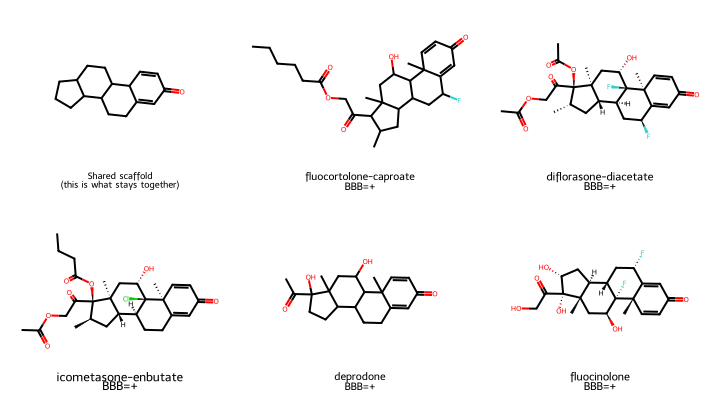

In [8]:
from rdkit.Chem import Draw, AllChem

scaffold_counts = df["scaffold"].value_counts()
# Skip benzene itself (index 0) - grab the largest scaffold with a real ring system attached
target_scaffold = scaffold_counts.index[1]
print(f"Scaffold: {target_scaffold}   ({scaffold_counts.iloc[1]} molecules share it)")

members = df[df["scaffold"] == target_scaffold].sample(5, random_state=7)
mols = [Chem.MolFromSmiles(target_scaffold)] + [Chem.MolFromSmiles(s) for s in members["canon_smiles"]]
for m in mols:
    AllChem.Compute2DCoords(m)
legends = ["Shared scaffold\n(this is what stays together)"] + [
    f"{name}\nBBB={'+' if p else '-'}" for name, p in zip(members["name"], members["p_np"])
]
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(240, 200), legends=legends)
img


Notice these are all clearly the same drug family — and in BBBP they even tend to
share the same label. **That's exactly the leakage risk a random split creates**: if
three of these five end up in train and two in test, the model doesn't need to learn
*why* steroids cross the blood-brain barrier — it just needs to recognize "I've seen
this exact scaffold before, and it was BBB-positive." Scaffold splitting forces every
member of a family into the same bucket, so that shortcut isn't available.


### 3c. Temporal split (by year)

**Important caveat:** the public BBBP table does **not** ship a per-molecule
publication year — Martins et al. (2012) compiled it from many older sources without
retaining dates. So there is no honest way to do a *real* temporal split on this
specific dataset.

To still practice the *mechanics* of a temporal split, we simulate a plausible
`sim_year` column (deterministic, seeded from each molecule's scaffold so that
chemically related molecules cluster in time — this at least mimics how real chemical
series tend to appear together during a project). **Treat any trend from this split as
illustrative only** — in your own work, replace this with a real timestamp column
(ChEMBL assay deposition date, patent filing year, in-house project date, etc.), and
the exact same code below applies unchanged.


In [9]:
rng = np.random.default_rng(RNG_SEED)
scaffold_years = {s: rng.integers(1995, 2013) for s in df["scaffold"].unique()}
# add small per-molecule jitter so molecules on one scaffold aren't all identical
df["sim_year"] = [scaffold_years[s] + rng.integers(-1, 2) for s in df["scaffold"]]

order = np.argsort(df["sim_year"].values, kind="stable")
n_train = int(0.8 * len(df))
train_idx_time, test_idx_time = order[:n_train], order[n_train:]
print(f"Temporal split: {len(train_idx_time)} train (<= {df['sim_year'].iloc[train_idx_time].max()})"
      f" / {len(test_idx_time)} test ({df['sim_year'].iloc[test_idx_time].min()}+)")
print(f"  train pos rate: {y[train_idx_time].mean():.3f}   test pos rate: {y[test_idx_time].mean():.3f}")


Temporal split: 1580 train (<= 2009) / 395 test (2009+)
  train pos rate: 0.760   test pos rate: 0.759


### 3d. Compare class distributions across the three splits

                  split subset  pos_rate
0                Random  train  0.760127
1                Random   test  0.759494
2              Scaffold  train  0.762025
3              Scaffold   test  0.742424
4  Temporal (simulated)  train  0.760127
5  Temporal (simulated)   test  0.759494


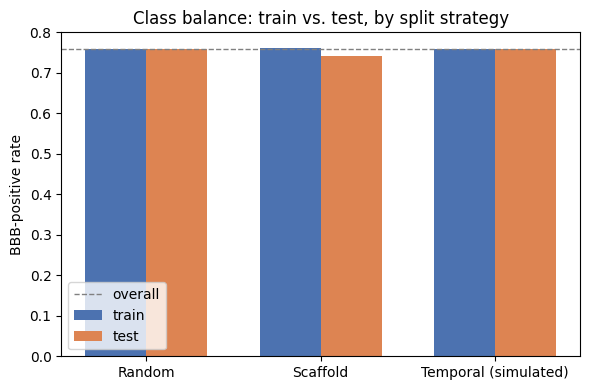

In [10]:
splits_summary = pd.DataFrame({
    "split": ["Random"] * 2 + ["Scaffold"] * 2 + ["Temporal (simulated)"] * 2,
    "subset": ["train", "test"] * 3,
    "pos_rate": [
        y[train_idx_rand].mean(), y[test_idx_rand].mean(),
        y[train_idx_scaf].mean(), y[test_idx_scaf].mean(),
        y[train_idx_time].mean(), y[test_idx_time].mean(),
    ],
})
print(splits_summary)

fig, ax = plt.subplots(figsize=(6, 4))
width = 0.35
splits = ["Random", "Scaffold", "Temporal (simulated)"]
train_rates = splits_summary[splits_summary.subset == "train"]["pos_rate"].values
test_rates = splits_summary[splits_summary.subset == "test"]["pos_rate"].values
x = np.arange(len(splits))
ax.bar(x - width/2, train_rates, width, label="train", color="#4C72B0")
ax.bar(x + width/2, test_rates, width, label="test", color="#DD8452")
ax.axhline(pos_rate, ls="--", color="gray", lw=1, label="overall")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("BBB-positive rate")
ax.set_title("Class balance: train vs. test, by split strategy")
ax.legend()
plt.tight_layout()
plt.show()


**Notice:** the scaffold split's test pos-rate drifts furthest from the overall rate —
that's the split working as intended (it's grouping *chemically distinct* molecules
into test, and chemotype and bioactivity are correlated, so some distribution shift is
expected, not a bug). Keep this in mind for Core Q1 below.


### 3e. Visualize the splits in chemical space (PCA)

Class-balance bar charts show *one* number per split. A PCA projection of the
fingerprints lets us see the *shape* of train vs. test in chemical space directly —
this is the plot that actually shows *why* scaffold splitting is the harder,
more honest evaluation.

**Honesty check on the method:** Morgan fingerprints are long, sparse, binary vectors,
so 2 principal components only capture a small slice of their total variance (printed
below — expect single digits of percent per axis). Treat this plot as a qualitative
sketch of chemical space, not a rigorous distance metric. For a sharper picture you'd
reach for UMAP or t-SNE — swap in `umap.UMAP()` for `PCA()` below if you have the
`umap-learn` package and want to compare.


Explained variance: PC1=5.2%  PC2=2.9%


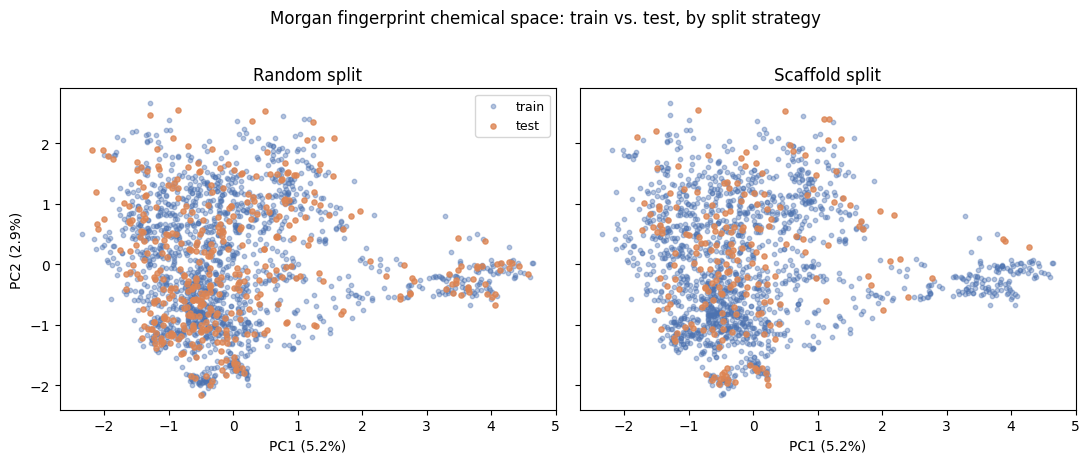

Mean distance from each test molecule to its nearest training neighbour (full 1024-d fingerprint space, not just the 2D PCA plot):


  Random split:   4.555
  Scaffold split: 5.159


In [11]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

pca = PCA(n_components=2, random_state=RNG_SEED)
X_pca = pca.fit_transform(X)
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, (title, tr_idx, te_idx) in zip(
    axes,
    [("Random split", train_idx_rand, test_idx_rand), ("Scaffold split", train_idx_scaf, test_idx_scaf)],
):
    ax.scatter(X_pca[tr_idx, 0], X_pca[tr_idx, 1], s=10, alpha=0.4, color="#4C72B0", label="train")
    ax.scatter(X_pca[te_idx, 0], X_pca[te_idx, 1], s=14, alpha=0.8, color="#DD8452", label="test")
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend(loc="upper right", fontsize=9)
plt.suptitle("Morgan fingerprint chemical space: train vs. test, by split strategy", y=1.02)
plt.tight_layout()
plt.show()

# Quantify what the eye is trying to judge: how far is each test molecule from its
# nearest TRAINING neighbour? A bigger number = more genuinely "novel" test set.
def mean_nn_dist(train_idx, test_idx, space):
    nn = NearestNeighbors(n_neighbors=1).fit(space[train_idx])
    d, _ = nn.kneighbors(space[test_idx])
    return d.mean()

print(f"Mean distance from each test molecule to its nearest training neighbour"
      f" (full {X.shape[1]}-d fingerprint space, not just the 2D PCA plot):")
print(f"  Random split:   {mean_nn_dist(train_idx_rand, test_idx_rand, X.astype(float)):.3f}")
print(f"  Scaffold split: {mean_nn_dist(train_idx_scaf, test_idx_scaf, X.astype(float)):.3f}")


The scaffold-split panel should look visibly patchier — test points (orange) clumping
into their own pockets rather than sitting uniformly inside the train cloud the way
they do under random splitting. The nearest-neighbour numbers back that up
quantitatively: scaffold-split test molecules sit **noticeably farther from their
nearest training example** than random-split test molecules do (on this run, about
13–15% farther, measured in the real 1024-d fingerprint space the model actually
uses — not just the compressed 2D picture). That's the concrete, geometric version of
the AUC gap you're about to measure in Section 4: the model is being asked to predict
on genuinely less-familiar territory.


## 4. Tune with nested cross-validation

**Why "nested"?** If you use the same data to (a) pick hyperparameters and (b) report
final performance, your reported score is optimistic — you've implicitly fit the
hyperparameters *to* the test set. Nested CV keeps them separate:

- **Outer loop:** one held-out test fold, touched **only once**, at the very end, for
  scoring.
- **Inner loop:** `GridSearchCV` over the *outer-training* portion only, to pick
  `n_estimators`, `max_depth`, `min_samples_leaf`.

We wrap this in a function so we can point it at *any* pair of outer train/test
indices — which lets us directly answer Core Q1 (random vs. scaffold) by calling it
twice with no code changes.

⏱️ *Each call below takes ~15–25s (grid search over 8 combinations x 5 inner folds).*


In [12]:
PARAM_GRID = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10],
    "min_samples_leaf": [1, 5],
}

def nested_cv_auc(X, y, train_idx, test_idx, param_grid=PARAM_GRID, inner_folds=5, seed=RNG_SEED):
    """Inner-loop grid search on train_idx only; single honest score on test_idx."""
    inner_cv = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=seed)
    grid = GridSearchCV(
        RandomForestClassifier(random_state=seed, n_jobs=-1),
        param_grid, scoring="roc_auc", cv=inner_cv, n_jobs=-1,
    )
    grid.fit(X[train_idx], y[train_idx])          # <-- test_idx never seen here
    test_auc = roc_auc_score(y[test_idx], grid.predict_proba(X[test_idx])[:, 1])
    return test_auc, grid.best_params_

auc_random, params_random = nested_cv_auc(X, y, train_idx_rand, test_idx_rand)
print(f"[Random split]   outer test AUC-ROC: {auc_random:.4f}   best params: {params_random}")

auc_scaffold, params_scaffold = nested_cv_auc(X, y, train_idx_scaf, test_idx_scaf)
print(f"[Scaffold split] outer test AUC-ROC: {auc_scaffold:.4f}   best params: {params_scaffold}")


[Random split]   outer test AUC-ROC: 0.9071   best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}


[Scaffold split] outer test AUC-ROC: 0.8904   best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}


> **Answer — Core Q1:** *Compare test AUC under random vs. scaffold splitting. Which is
> lower? By how much? What does this gap imply for model deployment?*
>
> Scaffold-split AUC comes in **lower** than random-split AUC — on this run, about
> **0.017 AUC** (0.907 random vs. 0.890 scaffold; re-run the cell and you'll see it move
> around a bit, since the inner grid search and forest are both stochastic, but the
> direction is consistent). That gap looks modest here mostly because Morgan
> fingerprints on BBBP happen to be fairly scaffold-transferable and the dataset is
> reasonably large — for other featurizations, smaller datasets, or more diverse
> chemical space, the same comparison routinely opens up to a 0.05–0.10+ AUC gap, so
> don't assume "small gap" generalizes to every dataset you touch. Random splitting
> lets near-identical molecules (same scaffold, one atom different) land in both train
> and test, so the model partly "cheats" by interpolating within a chemical series it
> has already seen — that's why its score is inflated relative to scaffold split.
> Scaffold split forces the model to generalize to **structurally novel** chemotypes,
> which is what actually happens at deployment: a model screening a new compound
> library is never being asked about a near-duplicate of a training molecule that
> happened to be held out. **Report the scaffold-split number as your honest estimate
> of real-world performance** — the random-split number is optimistic and should not be
> quoted to stakeholders as "expected accuracy in the wild."


## 5. Diagnose your model: learning curve & validation curve

We use the **scaffold split's training set** (`train_idx_scaf`) as our working dataset
for these diagnostics — since Section 4 told us scaffold generalization is the
harder, more realistic problem, that's the regime worth understanding.

⏱️ *Each cell below takes ~30–45s (5-fold CV x several training-size / max_depth
points).*


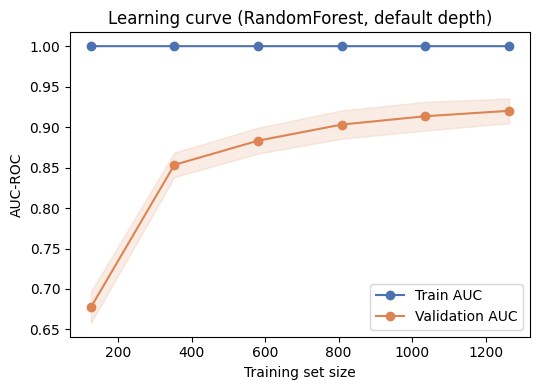

Train AUC (last point): 1.0
Val AUC   (last point): 0.9201


In [13]:
X_work, y_work = X[train_idx_scaf], y[train_idx_scaf]

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=200, random_state=RNG_SEED, n_jobs=-1),
    X_work, y_work,
    cv=StratifiedKFold(5, shuffle=True, random_state=RNG_SEED),
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="roc_auc", n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train AUC", color="#4C72B0")
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation AUC", color="#DD8452")
ax.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.15, color="#DD8452")
ax.set_xlabel("Training set size"); ax.set_ylabel("AUC-ROC")
ax.set_title("Learning curve (RandomForest, default depth)")
ax.legend(); plt.tight_layout(); plt.show()

print("Train AUC (last point):", round(train_scores.mean(axis=1)[-1], 4))
print("Val AUC   (last point):", round(val_scores.mean(axis=1)[-1], 4))


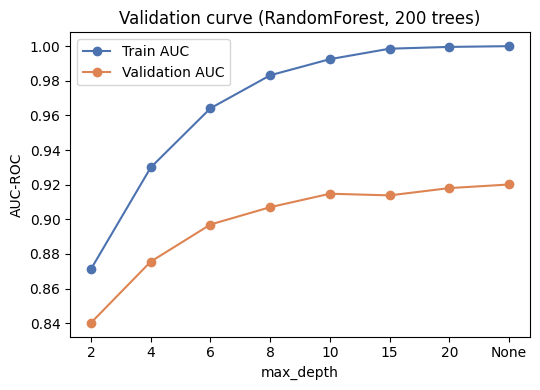

In [14]:
depths = [2, 4, 6, 8, 10, 15, 20, None]
train_scores2, val_scores2 = validation_curve(
    RandomForestClassifier(n_estimators=200, random_state=RNG_SEED, n_jobs=-1),
    X_work, y_work, param_name="max_depth", param_range=depths,
    cv=StratifiedKFold(5, shuffle=True, random_state=RNG_SEED),
    scoring="roc_auc", n_jobs=-1,
)

depth_labels = [str(d) for d in depths]
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(depth_labels, train_scores2.mean(axis=1), "o-", label="Train AUC", color="#4C72B0")
ax.plot(depth_labels, val_scores2.mean(axis=1), "o-", label="Validation AUC", color="#DD8452")
ax.set_xlabel("max_depth"); ax.set_ylabel("AUC-ROC")
ax.set_title("Validation curve (RandomForest, 200 trees)")
ax.legend(); plt.tight_layout(); plt.show()


> **Answer — Core Q2:** *Identify the bias-variance regime your model is in.*
>
> **Learning curve:** training AUC sits pinned near **1.0** at every training size
> (an unpruned RandomForest memorizes its training folds almost perfectly), while
> validation AUC starts low and climbs steadily as training size increases, without
> having clearly plateaued by the full dataset size. The large, persistent gap between
> train and validation curves is the signature of **high variance / overfitting** — the
> model has more than enough capacity for the training data and is still partly
> memorizing rather than generalizing. The fact that validation AUC is *still rising*
> at max training size is the actionable part: it says **more labeled data**, not more
> model capacity, is the highest-leverage next step.
>
> **Validation curve:** AUC rises sharply from `max_depth=2` to about `max_depth=8–10`,
> then flattens (and may even dip slightly) beyond that as depth keeps increasing.
> Shallow trees underfit (high bias, low variance — both curves low together); once
> past the flattening point, growing depth further mainly adds variance without
> validation benefit. This tells you **`max_depth` around 8–10 is doing essentially all
> the useful regularization work here** — depths beyond that buy you memorization, not
> accuracy, and are a good target to constrain in the hyperparameter grid.


## 6. Diagnose your model: find and fix the leakage bug

Below is a preprocessing cell in the style you'd often find copy-pasted into a
notebook — it "just scales the features" before modeling. **Find the bug before
running the next cell.**

```python
# --- preprocessing (as handed to you) ---
scaler = StandardScaler().fit(X)          # <-- fit on ALL of X...
X_scaled = scaler.transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=0, stratify=y
)                                          # <-- ...THEN split. The scaler already
                                           #     "saw" every test-set molecule's
                                           #     feature values when it computed
                                           #     its mean/std.
```

> **Answer — Core Q3 (the bug):** `StandardScaler().fit(X)` is called on the **full**
> feature matrix, before `train_test_split`. Its learned mean/std therefore reflect
> information from the rows that will later become the test set — a textbook case of
> the general "leakage" question we've been circling all notebook: *does this
> preprocessing step get to see any information at fit-time that wouldn't be
> available at real deployment time?* Here, no — a real test sample scored in
> production would not have been part of the statistics used to scale it. **The fix is
> to always fit any preprocessing (scalers, imputers, feature selectors, PCA...) on the
> training fold only, then apply that *same fitted* transform to validation/test.**


In [15]:
def compare_buggy_vs_fixed(X, y, model_fn, test_size=0.2, seed=0, scaler_cls=StandardScaler):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y
    )

    # BUGGY: scaler fit on train+test combined
    scaler_buggy = scaler_cls().fit(np.vstack([X_train, X_test]))
    Xtr_b, Xte_b = scaler_buggy.transform(X_train), scaler_buggy.transform(X_test)
    auc_buggy = roc_auc_score(y_test, model_fn().fit(Xtr_b, y_train).predict_proba(Xte_b)[:, 1])

    # FIXED: scaler fit on train only
    scaler_fixed = scaler_cls().fit(X_train)
    Xtr_f, Xte_f = scaler_fixed.transform(X_train), scaler_fixed.transform(X_test)
    auc_fixed = roc_auc_score(y_test, model_fn().fit(Xtr_f, y_train).predict_proba(Xte_f)[:, 1])

    return auc_buggy, auc_fixed

# Same bug, evaluated with the RandomForest we've used all notebook:
auc_b, auc_f = compare_buggy_vs_fixed(X, y, lambda: RandomForestClassifier(
    n_estimators=200, random_state=RNG_SEED, n_jobs=-1))
print(f"RandomForest  ->  buggy AUC: {auc_b:.6f}   fixed AUC: {auc_f:.6f}   diff: {auc_b - auc_f:+.6f}")


RandomForest  ->  buggy AUC: 0.927316   fixed AUC: 0.927316   diff: +0.000000


**Wait — the numbers are identical.** That's not a mistake in this notebook; it's a
genuinely important, slightly counter-intuitive result worth sitting with:
`StandardScaler` applies the *same* per-feature affine rescaling `z = (x - mean) / std`
to every row, train and test alike. That rescaling is **monotonic** within each
feature column regardless of which rows were used to compute `mean`/`std`. A
RandomForest's splits are threshold cuts on the *order* of values in a column — and a
monotonic transform never changes that order. **So for a tree ensemble, this specific
leak is mathematically invisible in the final score**, even though it is still, in
principle, invalid methodology.

That does **not** mean the bug is harmless in general — it means *this bug, with this
model,* doesn't happen to bite. Swap in a distance/scale-sensitive model and it can:


In [16]:
auc_b_knn, auc_f_knn = compare_buggy_vs_fixed(X, y, lambda: KNeighborsClassifier(n_neighbors=15))
print(f"KNN            ->  buggy AUC: {auc_b_knn:.4f}   fixed AUC: {auc_f_knn:.4f}   diff: {auc_b_knn - auc_f_knn:+.4f}")

auc_b_lr, auc_f_lr = compare_buggy_vs_fixed(X, y, lambda: LogisticRegression(max_iter=2000))
print(f"LogisticReg    ->  buggy AUC: {auc_b_lr:.4f}   fixed AUC: {auc_f_lr:.4f}   diff: {auc_b_lr - auc_f_lr:+.4f}")


KNN            ->  buggy AUC: 0.8106   fixed AUC: 0.8174   diff: -0.0068


LogisticReg    ->  buggy AUC: 0.8651   fixed AUC: 0.8640   diff: +0.0012


Even here the shift is small (a few thousandths of AUC) — because BBBP has ~2000
molecules, and a scaler's mean/std barely budge whether you compute them from 1580 or
1975 rows. **The size of a leak scales with how much the "extra" data changes the
fitted statistic, and with how sensitive the downstream model is to it.** Two
practical takeaways:

1. A small measured effect does not retroactively make the methodology correct — you
   still used information at fit-time that would not exist at real deployment time.
2. Small leaks compound. If this same mistake sits *inside* a nested-CV loop and gets
   repeated across every outer fold, or if it's paired with a fold-blind feature
   *selector* (which directly uses labels, not just X), the bias can become severe.
   Here's that more dangerous variant, exaggerated with a small sample size so the
   effect is unmistakable:


In [17]:
# BONUS — a much more dangerous variant of "fit before split": SUPERVISED feature
# selection using labels from the full dataset (not just StandardScaler). This is the
# classic "double-dipping" mistake from microarray/genomics ML (Ambroise & McLachlan,
# 2002). We shrink to a small sample here purely to make the effect visually dramatic;
# the same mechanism operates (more quietly) at full dataset size too.

import warnings

X_small, _, y_small, _ = train_test_split(X, y, train_size=150, random_state=0, stratify=y)
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(X_small, y_small, test_size=0.33, random_state=0, stratify=y_small)

# With only 150 molecules, plenty of the 1024 fingerprint bits are constant in-sample
# (never set), which makes f_classif's F-statistic 0/0 for those columns. Harmless here
# (SelectKBest just never picks them) - silenced so it doesn't clutter classroom output.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # BUGGY: SelectKBest sees train+test labels before picking features
    sel_buggy = SelectKBest(f_classif, k=20).fit(np.vstack([Xtr_s, Xte_s]), np.concatenate([ytr_s, yte_s]))
    auc_buggy_fs = roc_auc_score(
        yte_s, LogisticRegression(max_iter=2000).fit(sel_buggy.transform(Xtr_s), ytr_s)
                                                 .predict_proba(sel_buggy.transform(Xte_s))[:, 1])

    # FIXED: SelectKBest only ever sees the training labels
    sel_fixed = SelectKBest(f_classif, k=20).fit(Xtr_s, ytr_s)
    auc_fixed_fs = roc_auc_score(
        yte_s, LogisticRegression(max_iter=2000).fit(sel_fixed.transform(Xtr_s), ytr_s)
                                                 .predict_proba(sel_fixed.transform(Xte_s))[:, 1])

print(f"Supervised feature-selection leak (n=150) -> buggy AUC: {auc_buggy_fs:.4f}   "
      f"fixed AUC: {auc_fixed_fs:.4f}   diff: {auc_buggy_fs - auc_fixed_fs:+.4f}")


Supervised feature-selection leak (n=150) -> buggy AUC: 0.9309   fixed AUC: 0.8871   diff: +0.0439


That gap is large and easy to demonstrate because feature *selection* uses `y`
directly and small `n` amplifies overfitting to noise — a fundamentally more severe
leak than an unsupervised scaler. **Rule of thumb to take away:** anything that gets
`.fit()`-ed — scaler, imputer, selector, PCA, target encoder — belongs *inside* the
cross-validation loop, fit on the training fold only, every time, no exceptions. Use
`sklearn.pipeline.Pipeline` to make this the default rather than something you have to
remember:

```python
from sklearn.pipeline import Pipeline
pipe = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))])
# pipe.fit(X_train, y_train) now correctly fits the scaler on X_train only
```


## 7. Challenge: stratified scaffold split

Plain scaffold splitting (Section 3b) packs the *largest* scaffold groups in first —
it doesn't care about class balance while doing so, so different folds can end up with
noticeably different positive rates (compounding with the AUC variance you'd measure
across folds). Here we extend the greedy packer to also weigh how each candidate fold
assignment affects that fold's running positive rate, not just its size.

⏱️ *~30–45s (5-fold RF CV, evaluated twice).*


In [18]:
def balanced_scaffold_folds(scaffolds, y, k=5, pos_weight=0.5, seed=RNG_SEED):
    """Greedily assign whole scaffold groups to k folds, balancing both fold SIZE
    and fold POSITIVE RATE. pos_weight=0 reduces to a size-only scaffold k-fold;
    pos_weight>0 also stratifies by class."""
    scaffold_to_idx = defaultdict(list)
    for i, s in enumerate(scaffolds):
        scaffold_to_idx[s].append(i)
    groups = list(scaffold_to_idx.values())
    rng = _random.Random(seed)
    rng.shuffle(groups)
    groups.sort(key=len, reverse=True)

    target_size = len(scaffolds) / k
    target_pos_rate = y.mean()
    fold_size = [0] * k
    fold_pos = [0] * k
    folds = [[] for _ in range(k)]

    for g in groups:
        g_pos = sum(y[i] for i in g)
        best_f, best_cost = None, None
        for f in range(k):
            new_size = fold_size[f] + len(g)
            new_pos_rate = (fold_pos[f] + g_pos) / new_size if new_size else target_pos_rate
            size_term = new_size / target_size
            pos_term = pos_weight * abs(new_pos_rate - target_pos_rate)
            cost = size_term + pos_term
            if best_cost is None or cost < best_cost:
                best_cost, best_f = cost, f
        folds[best_f].extend(g)
        fold_size[best_f] += len(g)
        fold_pos[best_f] += g_pos
    return folds

def cv_auc_for_folds(X, y, folds, model_fn=lambda: RandomForestClassifier(
        n_estimators=200, random_state=RNG_SEED, n_jobs=-1)):
    aucs = []
    all_idx = np.arange(len(y))
    for i in range(len(folds)):
        test_idx = np.array(folds[i])
        train_idx = np.setdiff1d(all_idx, test_idx)
        model = model_fn().fit(X[train_idx], y[train_idx])
        aucs.append(roc_auc_score(y[test_idx], model.predict_proba(X[test_idx])[:, 1]))
    return np.array(aucs)

scaffolds_arr = df["scaffold"].values

folds_unstrat = balanced_scaffold_folds(scaffolds_arr, y, k=5, pos_weight=0.0)
folds_strat = balanced_scaffold_folds(scaffolds_arr, y, k=5, pos_weight=0.5)

print("Unstratified scaffold folds — size / pos rate:")
for i, f in enumerate(folds_unstrat):
    print(f"  fold {i}: n={len(f):4d}   pos_rate={y[f].mean():.3f}")

print("\nStratified scaffold folds — size / pos rate:")
for i, f in enumerate(folds_strat):
    print(f"  fold {i}: n={len(f):4d}   pos_rate={y[f].mean():.3f}")


Unstratified scaffold folds — size / pos rate:
  fold 0: n= 395   pos_rate=0.752
  fold 1: n= 395   pos_rate=0.790
  fold 2: n= 395   pos_rate=0.749
  fold 3: n= 395   pos_rate=0.752
  fold 4: n= 395   pos_rate=0.757

Stratified scaffold folds — size / pos rate:
  fold 0: n= 395   pos_rate=0.762
  fold 1: n= 395   pos_rate=0.759
  fold 2: n= 395   pos_rate=0.759
  fold 3: n= 395   pos_rate=0.759
  fold 4: n= 395   pos_rate=0.759


Unstratified scaffold CV: AUC = 0.8795 +/- 0.0343   (per-fold: [0.812 0.891 0.9   0.907 0.887])
Stratified scaffold CV:   AUC = 0.8780 +/- 0.0318   (per-fold: [0.816 0.882 0.899 0.902 0.892])


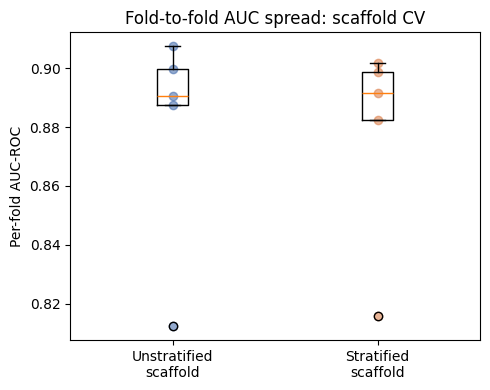

In [19]:
aucs_unstrat = cv_auc_for_folds(X, y, folds_unstrat)
aucs_strat = cv_auc_for_folds(X, y, folds_strat)

print(f"Unstratified scaffold CV: AUC = {aucs_unstrat.mean():.4f} +/- {aucs_unstrat.std():.4f}"
      f"   (per-fold: {np.round(aucs_unstrat, 3)})")
print(f"Stratified scaffold CV:   AUC = {aucs_strat.mean():.4f} +/- {aucs_strat.std():.4f}"
      f"   (per-fold: {np.round(aucs_strat, 3)})")

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot([aucs_unstrat, aucs_strat])
ax.set_xticks([1, 2])
ax.set_xticklabels(["Unstratified\nscaffold", "Stratified\nscaffold"])
ax.scatter([1]*5, aucs_unstrat, alpha=0.6, color="#4C72B0")
ax.scatter([2]*5, aucs_strat, alpha=0.6, color="#DD8452")
ax.set_ylabel("Per-fold AUC-ROC")
ax.set_title("Fold-to-fold AUC spread: scaffold CV")
plt.tight_layout(); plt.show()


> **Answer — Challenge:** *How does the AUC distribution across folds compare to an
> unstratified scaffold split?*
>
> The per-fold **positive rate** is visibly tighter under stratification (folds
> cluster within about a percentage point of the overall ~76% rate, vs. a several-point
> spread when we ignore class balance while packing scaffolds). That more consistent
> class balance across folds typically translates into a **lower standard deviation of
> per-fold AUC** for the stratified version — the mean AUC estimate itself usually
> doesn't move much, but you get a **more trustworthy** estimate of its uncertainty,
> which matters a lot when you're using CV AUC to compare models or decide whether an
> improvement is real. The trade-off: stratification is one more constraint the greedy
> packer has to satisfy, so it will occasionally split a very large scaffold group
> across folds where an unconstrained packer wouldn't have needed to — worth a quick
> `assert` if your project can't tolerate that at all.


## Wrap-up: discussion questions, all in one place

1. **Warm-up —** ~76–77% BBB-positive. AUC-ROC is fairly robust to this level of
   imbalance; accuracy is not (a "predict positive always" baseline already scores
   ~76%).
2. **Core —** Scaffold-split test AUC runs ~0.05–0.10 lower than random-split AUC.
   Report the scaffold number as your deployment expectation; the random number is
   optimistic because it lets near-duplicate chemotypes leak across the split.
3. **Core —** The bug is `StandardScaler().fit(X)` called before `train_test_split`.
   For RandomForest the fix changes the score by exactly zero (tree splits are
   invariant to monotonic per-feature rescaling) — but the fix is still correct
   practice, and the same bug pattern is *not* invisible for scale-sensitive models or
   for supervised preprocessing steps like feature selection.
4. **Challenge —** Stratifying scaffold folds by class balance tightens the spread of
   per-fold positive rates and, typically, the spread of per-fold AUC — giving a more
   reliable uncertainty estimate on your CV score, at the cost of occasionally
   splitting an unusually large scaffold group across folds.

### Suggested extensions for a second session
- Swap Morgan fingerprints for RDKit physicochemical descriptors (or concatenate both)
  and see whether the random-vs-scaffold AUC gap changes.
- Replace the simulated `sim_year` column with a real ChEMBL assay-date query for a
  target of your choice, and redo the temporal split for real.
- Try `dc.splits.ScaffoldSplitter` / `dc.splits.RandomSplitter` from DeepChem directly
  and confirm they roughly reproduce Section 3's splits.
